In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.stats import mannwhitneyu
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler 
plt.style.use('ggplot')
import itertools as it

# extend the print line width
np.set_printoptions(linewidth=200)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

#suppress runtimewarnings
import warnings 
warnings.filterwarnings("ignore", category=RuntimeWarning)

# tuh feature path and description
feature_path = '/space/gzanardini/tuh_whole/split/'
feature_list = [file for file in os.listdir(feature_path) if file.endswith('.npy')]
description = pd.read_csv(os.path.join(feature_path, 'description.csv'))
labels = description['epilepsy'].values

# Mann-Whitney U test function
def mann_whitney_u_test(x, y):
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    return p

def handle_complex_numbers(features):
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

# Sort the feature list
feature_list.sort()

feature_names = ['cc', 'cwt', 'dwt', 'gcc', 'gplv', 'plv', 'mst', 'sst', 'spectral', 'utm']
combiners=['mean', 'median', 'std', 'skew','kurt']
montages = ['CAR', 'BipolarDB','Cz','Laplacian']
segment_lengths=[1,2,5,10, 20, 60]

feature_dict = {}
for feature in feature_names:
    feature_dict[feature] = [f for f in feature_list if f.startswith(feature)]

In [3]:
lowest_pval_df = pd.DataFrame(columns=["Montage", "SegLength", 'Combiner', 'Feature Index', "LowestPValue"], index=feature_names)

significant_features_df = pd.DataFrame(columns=["FeatureName", "Montage", "SegLength", "Combiner", "FeaturesIndexs", "PValues" ])
# Create a DataFrame to store the lowest p-values and corresponding parameters for each feature

for feature in feature_names:
    lowest_pval_df.loc[feature, :] = [None, None, None, None, np.inf]
 
    for idx, (montage, segment_length, combiner) in enumerate(it.product(montages, segment_lengths, combiners)):
        print(feature, idx, montage, segment_length, combiner)
        feature_file = f"{feature}_{montage}_{segment_length}s_{combiner}.npy"
        features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
        features = handle_complex_numbers(features)

        ps=np.array([mann_whitney_u_test(features[labels==0][:, i], features[labels==1][:, i]) for i in range(features.shape[1])])
        #apply bonferroni correction
        ps = ps * features.shape[1]
        ps = np.clip(ps, 0, 1)     
        lowest_indices = np.where(ps < 0.05)[0]
        lowest_indices_sorted = lowest_indices[np.argsort(ps[lowest_indices])]
        lowest_10 = lowest_indices_sorted[:10]
 
        significant = pd.DataFrame({
            "FeatureName": feature,
            "Montage": montage,
            "SegLength": segment_length,
            "Combiner": combiner,
            "FeaturesIndexs": lowest_indices_sorted.tolist(),
            "PValues": ps[lowest_indices_sorted].tolist()
        })

        significant_features_df = pd.concat([significant_features_df, significant], ignore_index=True)

        # Update the lowest p-value DataFrame
        if len(lowest_indices) > 0 and min(ps[lowest_indices]) < lowest_pval_df.loc[feature, 'LowestPValue']:
            lowest_pval_df.loc[feature, 'Montage'] = montage
            lowest_pval_df.loc[feature, 'SegLength'] = segment_length
            lowest_pval_df.loc[feature, 'Combiner'] = combiner
            lowest_pval_df.loc[feature, 'Feature Index'] = lowest_indices_sorted[0]
            lowest_pval_df.loc[feature, 'LowestPValue'] = ps[lowest_indices_sorted[0]]


cc 0 CAR 1 mean
cc 1 CAR 1 median
cc 2 CAR 1 std
cc 3 CAR 1 skew
cc 4 CAR 1 kurt
cc 5 CAR 2 mean
cc 6 CAR 2 median
cc 7 CAR 2 std
cc 8 CAR 2 skew
cc 9 CAR 2 kurt
cc 10 CAR 5 mean
cc 11 CAR 5 median
cc 12 CAR 5 std
cc 13 CAR 5 skew
cc 14 CAR 5 kurt
cc 15 CAR 10 mean
cc 16 CAR 10 median
cc 17 CAR 10 std
cc 18 CAR 10 skew
cc 19 CAR 10 kurt
cc 20 CAR 20 mean
cc 21 CAR 20 median
cc 22 CAR 20 std
cc 23 CAR 20 skew
cc 24 CAR 20 kurt
cc 25 CAR 60 mean
cc 26 CAR 60 median
cc 27 CAR 60 std
cc 28 CAR 60 skew
cc 29 CAR 60 kurt
cc 30 BipolarDB 1 mean
cc 31 BipolarDB 1 median
cc 32 BipolarDB 1 std
cc 33 BipolarDB 1 skew
cc 34 BipolarDB 1 kurt
cc 35 BipolarDB 2 mean
cc 36 BipolarDB 2 median
cc 37 BipolarDB 2 std
cc 38 BipolarDB 2 skew
cc 39 BipolarDB 2 kurt
cc 40 BipolarDB 5 mean
cc 41 BipolarDB 5 median
cc 42 BipolarDB 5 std
cc 43 BipolarDB 5 skew
cc 44 BipolarDB 5 kurt
cc 45 BipolarDB 10 mean
cc 46 BipolarDB 10 median
cc 47 BipolarDB 10 std
cc 48 BipolarDB 10 skew
cc 49 BipolarDB 10 kurt
cc 50 Bipo

In [4]:
lowest_pval_df

,Montage,SegLength,Combiner,Feature Index,LowestPValue
cc,BipolarDB,2,mean,37,0.026633
cwt,CAR,5,skew,194,0.035095
dwt,Cz,20,skew,76,0.024093
gcc,CAR,1,std,19,0.036334
gplv,None,None,None,None,inf
plv,None,None,None,None,inf
mst,None,None,None,None,inf
sst,Laplacian,20,skew,106,0.027942
spectral,CAR,60,std,37,0.024511
utm,Cz,1,mean,205,0.014756


In [6]:
#for each of the significant feature, compute the effect size   r_rb = 1 - (2 * u_stat) / (n1 * n2)
effect_sizes = []
for index, row in significant_features_df.iterrows():
    feature_name = row['FeatureName']
    montage = row['Montage']
    seg_length = row['SegLength']
    combiner = row['Combiner']
    feature_indices = row['FeaturesIndexs']
    p_values = row['PValues']

    # if feature indices are not a list, convert them
    if not isinstance(feature_indices, list):
        feature_indices = [feature_indices]
    if not isinstance(p_values, list):
        p_values = [p_values]

    for (feature_index, p_value) in zip(feature_indices, p_values):
        feature_file = f"{feature_name}_{montage}_{seg_length}s_{combiner}.npy"
        features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
        features = handle_complex_numbers(features)

        healthy_values = features[labels == 0][:, feature_index]
        epileptic_values = features[labels == 1][:, feature_index]

        n1 = len(healthy_values)
        n2 = len(epileptic_values)
        u_stat, _ = mannwhitneyu(healthy_values, epileptic_values)

        r_rb = 1 - (2 * u_stat) / (n1 * n2)
        effect_sizes.append({
            "FeatureName": feature_name,
            "Montage": montage,
            "SegLength": seg_length,
            "Combiner": combiner,
            "FeatureIndex": feature_index,
            "PValue": p_value,
            "EffectSize": r_rb
        })

effect_sizes_df = pd.DataFrame(effect_sizes)
effect_sizes_df

,FeatureName,Montage,SegLength,Combiner,FeatureIndex,PValue,EffectSize
0,cc,BipolarDB,2,mean,37,0.026633,-0.743590
1,cc,BipolarDB,5,mean,37,0.037501,-0.726496
2,cc,BipolarDB,10,mean,37,0.037501,-0.726496
3,cc,BipolarDB,20,mean,37,0.033485,-0.732194
4,cc,BipolarDB,60,mean,37,0.037501,-0.726496
5,cwt,CAR,5,skew,194,0.035095,0.789174
6,cwt,CAR,5,kurt,194,0.039618,0.783476
7,cwt,CAR,20,skew,457,0.044687,0.777778
8,cwt,BipolarDB,5,skew,298,0.045329,0.772080
9,cwt,BipolarDB,20,kurt,350,0.045329,0.772080


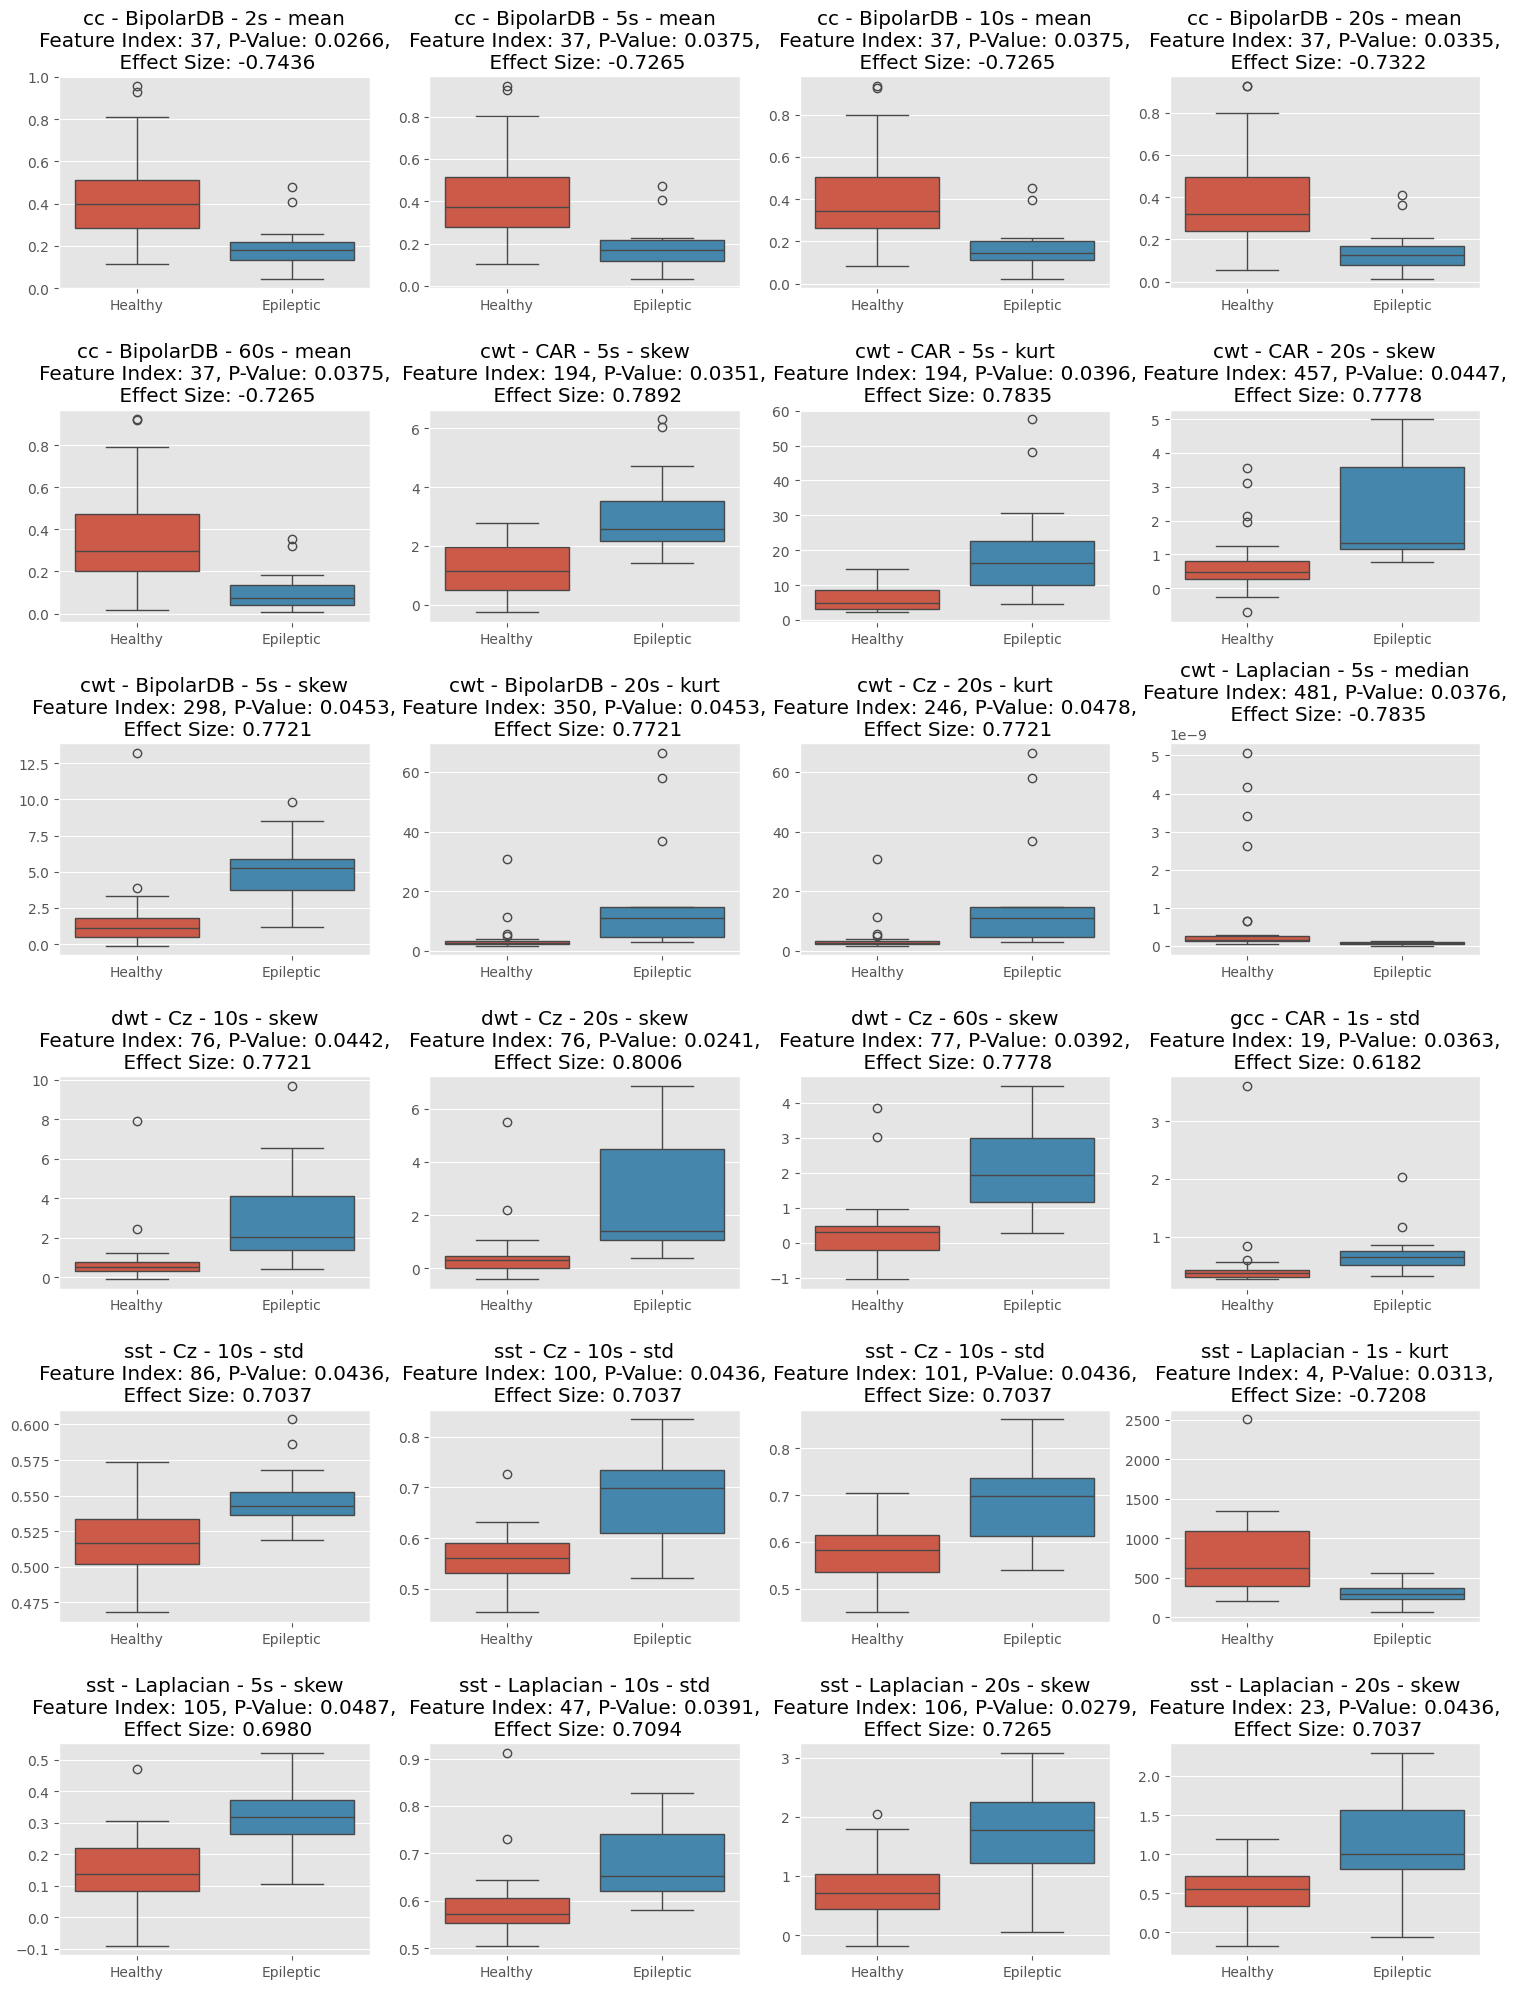

In [10]:
#print in figures with a 6x4 grid the boxplots of the features with the lowest p-values, include effect size  and p value in the title
# one plot per each row of effect_sizes_df, separating epileptic and healthy values,
fig, axes = plt.subplots(6,4, figsize=(15, 20))

for index, row in effect_sizes_df[:24].iterrows():
    feature_name = row['FeatureName']
    montage = row['Montage']
    seg_length = row['SegLength']
    combiner = row['Combiner']
    feature_index = row['FeatureIndex']
    p_value = row['PValue']
    effect_size = row['EffectSize']

    feature_file = f"{feature_name}_{montage}_{seg_length}s_{combiner}.npy"
    features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
    features = handle_complex_numbers(features)

    healthy_values = features[labels == 0][:, feature_index]
    epileptic_values = features[labels == 1][:, feature_index]

    # grid is 6x4, iterate over the index to find the correct subplot
    ax = axes[index // 4, index % 4]
    sns.boxplot(data=[healthy_values, epileptic_values], ax=ax)
    ax.set_title(f"{feature_name} - {montage} - {seg_length}s - {combiner}\n"
                 f"Feature Index: {feature_index}, P-Value: {p_value:.4f},\n Effect Size: {effect_size:.4f}", )
    ax.set_xticks([0, 1])

    ax.set_xticklabels(['Healthy', 'Epileptic'])
plt.tight_layout()


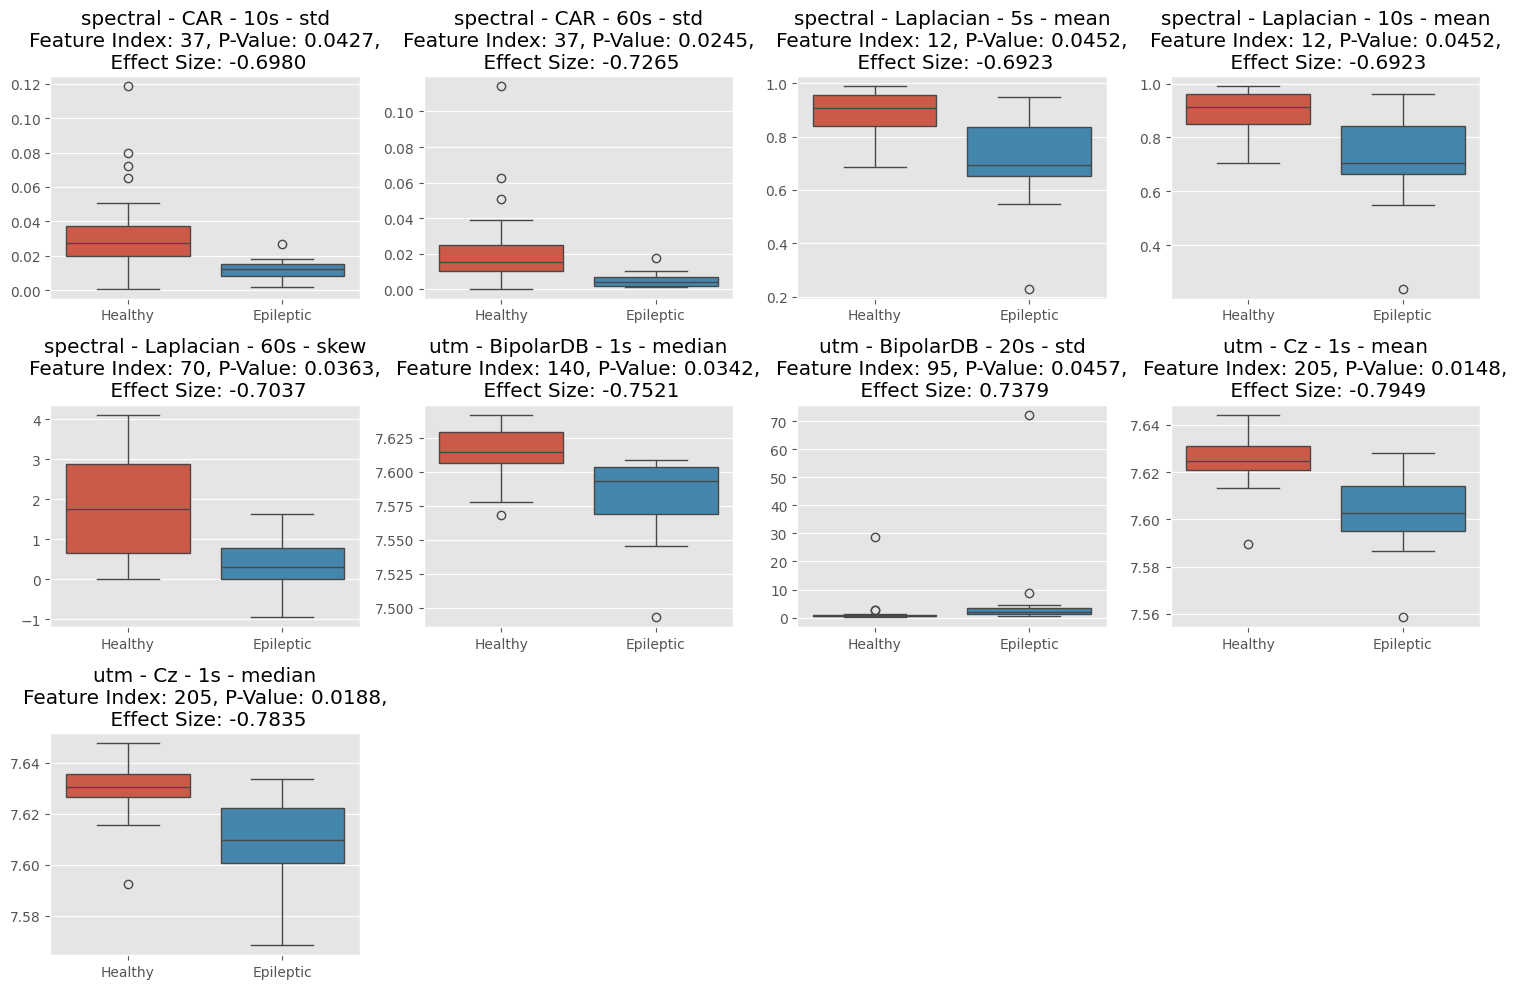

In [22]:

fig, axes = plt.subplots(3,4 , figsize=(15, 10))

for local_idx, (_, row) in enumerate(effect_sizes_df[24:].iterrows()):
    feature_name = row['FeatureName']
    montage = row['Montage']
    seg_length = row['SegLength']
    combiner = row['Combiner']
    feature_index = row['FeatureIndex']
    p_value = row['PValue']
    effect_size = row['EffectSize']

    feature_file = f"{feature_name}_{montage}_{seg_length}s_{combiner}.npy"
    features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
    features = handle_complex_numbers(features)

    healthy_values = features[labels == 0][:, feature_index]
    epileptic_values = features[labels == 1][:, feature_index]

    ax = axes[local_idx // 4, local_idx % 4]
    sns.boxplot(data=[healthy_values, epileptic_values], ax=ax)
    ax.set_title(f"{feature_name} - {montage} - {seg_length}s - {combiner}\n"
                 f"Feature Index: {feature_index}, P-Value: {p_value:.4f},\n Effect Size: {effect_size:.4f}")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy', 'Epileptic'])

    if local_idx == 9:
        break

#delete the empty subplots
for i in range(local_idx + 1, 12):
    fig.delaxes(axes[i // 4, i % 4])

plt.tight_layout()#
plt.show()
# Save the significant features DataFrame to a CSV fil



